# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 90 dias | Ventana salida: 1 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [75]:
VENTANA_ENTRADA = 90   # dias de entrada
VENTANA_SALIDA  = 1   # dias de salida (promedio)


In [77]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import regularizers
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import (
    construir_dense, construir_dense_v2, construir_dense_v3,
    construir_dense_v4, construir_dense_v5, construir_dense_v6,
    construir_recurrente, construir_recurrente_v2, construir_recurrente_v3,
    construir_recurrente_v4, construir_recurrente_v5, construir_recurrente_v6,
    construir_conv1d, construir_conv1d_v2, construir_conv1d_v3,
    construir_conv1d_v4, construir_conv1d_v5, construir_conv1d_v6,
    construir_mixto,
)
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae
CALLBACKS = [
    EarlyStopping(patience=10000, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.1, patience=500, verbose=1),
]



---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [78]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16100, 90, 23)  |  y: (16100, 23)
Train: (13041, 90, 23)  Val: (1449, 90, 23)  Test: (1610, 90, 23)


## 1.2 Baselines

In [79]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.011190  0.010370  0.014121         0
BuyAndHold   0.011859  0.009026  0.012271         0


## 1.3 Modelos Dense (MLP)

In [80]:
def aplicar_hp(modelo, lr=None, l2=None):
    """Aplica lr y/o L2 a un modelo ya construido sin reiniciar Keras."""
    if lr is not None:
        modelo.optimizer.learning_rate.assign(lr)
    if l2 is not None:
        reg = regularizers.l2(l2)
        for layer in modelo.layers:
            if hasattr(layer, "kernel"):
                layer.kernel_regularizer = reg
        # recompila solo la funcion de perdida; el optimizer y sus pesos se conservan
        modelo.compile(optimizer=modelo.optimizer, loss=modelo.loss)


In [81]:
modelo_dense = construir_dense(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense, lr=1e-4, l2=1e-4)
modelo_dense.summary()
hist_dense = modelo_dense.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=250, batch_size=100000, verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 566,039 (2.16 MB)

 Trainable params: 566,039 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step - loss: 0.0212 - val_loss: 0.0139
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0207 - val_loss: 0.0135
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0203 - val_loss: 0.0132
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0199 - val_loss: 0.0129
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0195 - val_loss: 0.0126
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0191 - val_loss: 0.0124
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0188 - val_loss: 0.0121
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0184 - val_loss: 0.0119
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0182 - val_loss: 0.0117
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.0179 - val_loss: 0.0116
Epoch 11/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0176 - val_loss: 0.0114
Epoch 12/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0

{'modelo': 'Dense', 'mae_train': 0.011318479853771702, 'mae_val': 0.009100660906148922, 'mae_test': 0.012443191915350352, 'n_params': 566039}


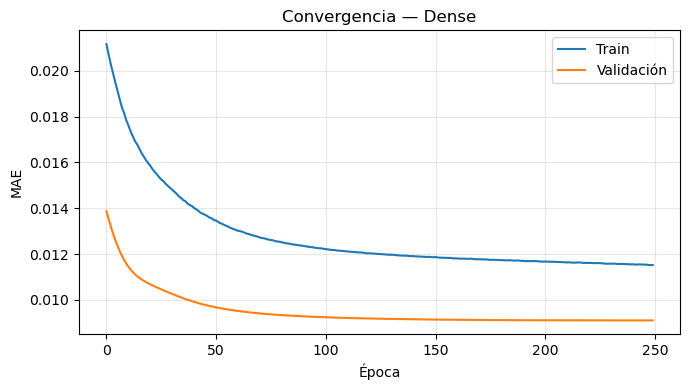

In [82]:
graficar_convergencia(hist_dense, 'Dense')
resultado_dense = evaluar_modelo(modelo_dense, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense)

### Dense v2 -- 3 capas estrechas (128->64->32), Dropout 0.3

In [83]:
modelo_dense_v2 = construir_dense_v2(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v2, lr=1e-4, l2=1e-14)
modelo_dense_v2.summary()
hist_dense_v2 = modelo_dense_v2.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=500, batch_size=13765 , verbose=1)

Model: "Dense_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,183 (1.05 MB)

 Trainable params: 276,183 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step - loss: 0.0201 - val_loss: 0.0115
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0198 - val_loss: 0.0113
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0194 - val_loss: 0.0111
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0191 - val_loss: 0.0110
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0188 - val_loss: 0.0108
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0185 - val_loss: 0.0106
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0181 - val_loss: 0.0105
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0178 - val_loss: 0.0104
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0175 - val_loss: 0.0102
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0174 - val_loss: 0.0101
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0171 - val_loss: 0.0100
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.01

{'modelo': 'Dense_v2', 'mae_train': 0.011799416001875356, 'mae_val': 0.009041363493514231, 'mae_test': 0.012287000237994209, 'n_params': 276183}


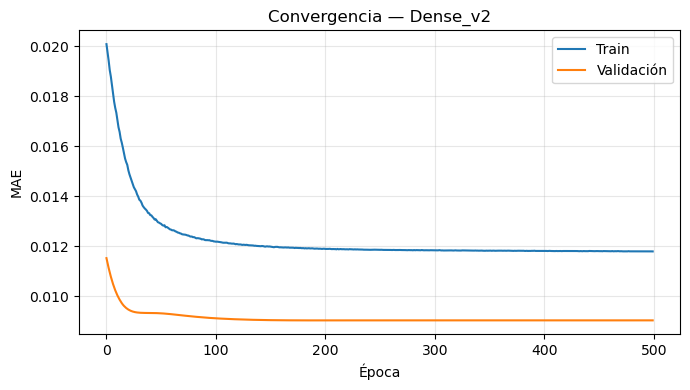

In [84]:
graficar_convergencia(hist_dense_v2, 'Dense_v2')
resultado_dense_v2 = evaluar_modelo(modelo_dense_v2, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v2')
print(resultado_dense_v2)

### Dense v3 -- 4 capas anchas (512->256->128->64), LR=1e-4

In [85]:
modelo_dense_v3 = construir_dense_v3(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v3, lr=1e-4, l2=1e-2)
modelo_dense_v3.summary()
hist_dense_v3 = modelo_dense_v3.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=200, batch_size=13765 ,   verbose=1)

Model: "Dense_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                │ (None, 512)            │     1,060,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,234,327 (4.71 MB)

 Trainable params: 1,234,327 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step - loss: 0.0138 - val_loss: 0.0099
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0136 - val_loss: 0.0098
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0133 - val_loss: 0.0096
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - loss: 0.0131 - val_loss: 0.0096
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0130 - val_loss: 0.0095
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 0.0129 - val_loss: 0.0094
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 0.0128 - val_loss: 0.0094
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.0127 - val_loss: 0.0093
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.0126 - val_loss: 0.0093
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.0125 - val_loss: 0.0093
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.0124 - val_loss: 0.0093
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 0.0

{'modelo': 'Dense_v3', 'mae_train': 0.011356108956442896, 'mae_val': 0.009076895249415424, 'mae_test': 0.012340573619442071, 'n_params': 1234327}


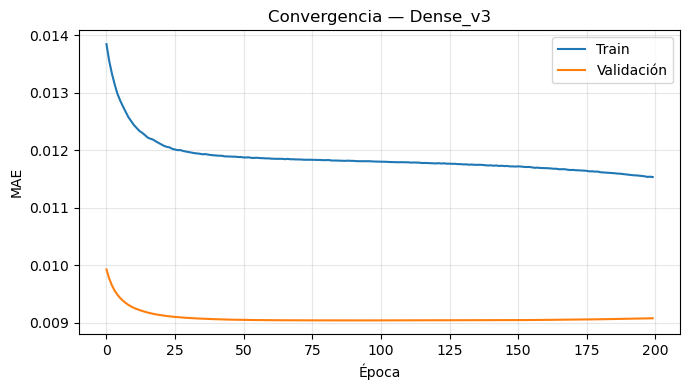

In [86]:
graficar_convergencia(hist_dense_v3, 'Dense_v3')
resultado_dense_v3 = evaluar_modelo(modelo_dense_v3, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v3')
print(resultado_dense_v3)

### Dense v4 -- 2 capas con regularizacion L2 (128->64)

In [87]:
modelo_dense_v4 = construir_dense_v4(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v4, lr=1e-3, l2=1e-100)
modelo_dense_v4.summary()
hist_dense_v4 = modelo_dense_v4.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=400, batch_size=13765 ,   verbose=1)

Model: "Dense_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_73 (Dense)                │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,839 (1.05 MB)

 Trainable params: 274,839 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step - loss: 0.0539 - val_loss: 0.0440
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0502 - val_loss: 0.0418
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0473 - val_loss: 0.0402
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0450 - val_loss: 0.0390
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0432 - val_loss: 0.0379
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0416 - val_loss: 0.0369
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0403 - val_loss: 0.0359
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0390 - val_loss: 0.0349
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0379 - val_loss: 0.0339
Epoch 10/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0368 - val_loss: 0.0329
Epoch 11/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0358 - val_loss: 0.0320
Epoch 12/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0

{'modelo': 'Dense_v4', 'mae_train': 0.011842923524950248, 'mae_val': 0.009039735113525772, 'mae_test': 0.012282286265894761, 'n_params': 274839}


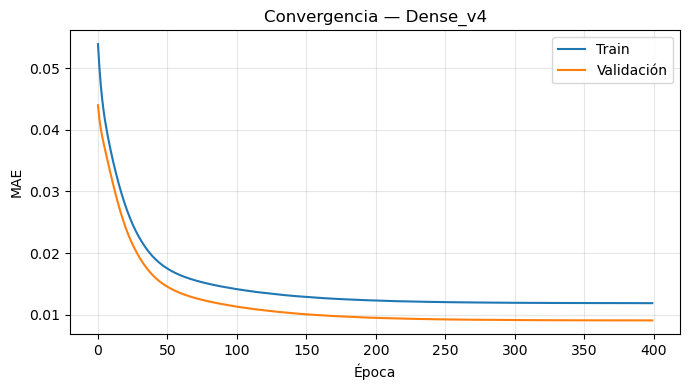

In [88]:
graficar_convergencia(hist_dense_v4, 'Dense_v4')
resultado_dense_v4 = evaluar_modelo(modelo_dense_v4, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v4')
print(resultado_dense_v4)

### Dense v5 -- 1 capa oculta grande (256) con activacion tanh

In [89]:
modelo_dense_v5 = construir_dense_v5(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v5, lr=1e-3, l2=1e-4)
modelo_dense_v5.summary()
hist_dense_v5 = modelo_dense_v5.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=300, batch_size=13765 ,   verbose=1)

Model: "Dense_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_76 (Dense)                │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,087 (2.05 MB)

 Trainable params: 536,087 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - loss: 0.0299 - val_loss: 0.0196
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0278 - val_loss: 0.0179
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0257 - val_loss: 0.0168
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0242 - val_loss: 0.0161
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0232 - val_loss: 0.0156
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0224 - val_loss: 0.0150
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0217 - val_loss: 0.0145
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0210 - val_loss: 0.0141
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0203 - val_loss: 0.0136
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0196 - val_loss: 0.0130
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0189 - val_loss: 0.0126
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.0

{'modelo': 'Dense_v5', 'mae_train': 0.010534718262673642, 'mae_val': 0.00990522082970493, 'mae_test': 0.013492791860965548, 'n_params': 536087}


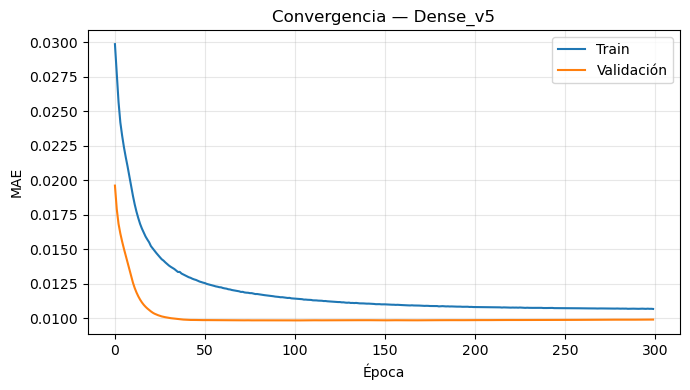

In [90]:
graficar_convergencia(hist_dense_v5, 'Dense_v5')
resultado_dense_v5 = evaluar_modelo(modelo_dense_v5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v5')
print(resultado_dense_v5)

### Dense v6 -- arquitectura piramidal inversa (32->64->128), activacion elu

In [91]:
modelo_dense_v6 = construir_dense_v6(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v6, lr=5e-4, l2=1e-5)
modelo_dense_v6.summary()
hist_dense_v6 = modelo_dense_v6.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=300, batch_size=13765 ,   verbose=1)

Model: "Dense_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_78 (Dense)                │ (None, 32)             │        66,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,671 (311.21 KB)

 Trainable params: 79,671 (311.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step - loss: 0.0222 - val_loss: 0.0145
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0215 - val_loss: 0.0139
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0208 - val_loss: 0.0134
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0201 - val_loss: 0.0131
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0195 - val_loss: 0.0127
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0190 - val_loss: 0.0124
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0184 - val_loss: 0.0121
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0179 - val_loss: 0.0118
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0175 - val_loss: 0.0116
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0171 - val_loss: 0.0113
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0167 - val_loss: 0.0111
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0164 - val

{'modelo': 'Dense_v6', 'mae_train': 0.011062609759198986, 'mae_val': 0.009410725079951117, 'mae_test': 0.01278305789613441, 'n_params': 79671}


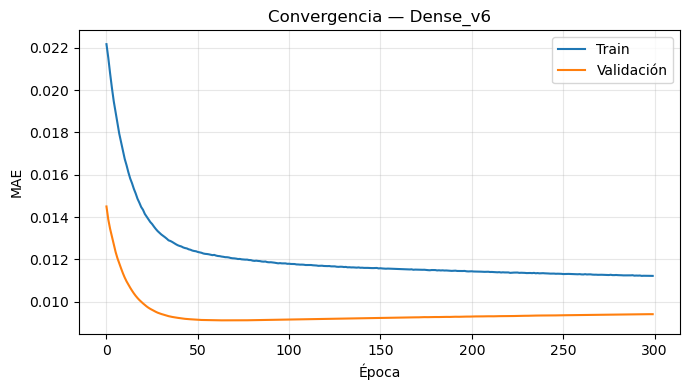

In [92]:
graficar_convergencia(hist_dense_v6, 'Dense_v6')
aplicar_hp(modelo_dense_v6, lr=5e-4, l2=1e-5)

resultado_dense_v6 = evaluar_modelo(modelo_dense_v6, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v6')
print(resultado_dense_v6)

## 1.4 Modelos Recurrentes (LSTM / GRU)

In [93]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_lstm, lr=1e-2, l2=1e-2)
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                  │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0123 - val_loss: 0.0220
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step - loss: 0.0243 - val_loss: 0.0130
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0158 - val_loss: 0.0114
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0143 - val_loss: 0.0116
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0144 - val_loss: 0.0107
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0137 - val_loss: 0.0101
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step - loss: 0.0133 - val_loss: 0.0098
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0131 - val_loss: 0.0099
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step - loss: 0.0130 - val_loss: 0.0097
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step - loss: 0.0129 - val_loss: 0.0095
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step - loss: 0.0127 - val_loss: 0.0094
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step - loss: 0.0126 - val_loss: 0.

{'modelo': 'LSTM', 'mae_train': 0.01181338127782195, 'mae_val': 0.009069891977756202, 'mae_test': 0.012312343943062097, 'n_params': 24023}


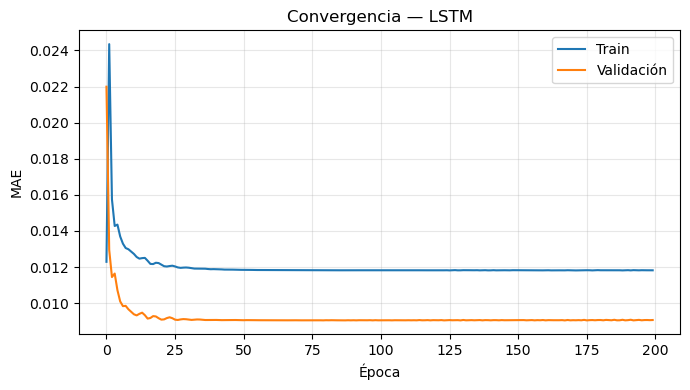

In [94]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)

### Recurrente v2 -- 2 capas LSTM apiladas (64->32)

In [95]:
modelo_lstm_v2 = construir_recurrente_v2(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_lstm_v2, lr=1e-2, l2=1e-100)
modelo_lstm_v2.summary()
hist_lstm_v2 = modelo_lstm_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "LSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0120 - val_loss: 0.0363
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0388 - val_loss: 0.0159
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0185 - val_loss: 0.0127
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0154 - val_loss: 0.0135
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0158 - val_loss: 0.0116
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0141 - val_loss: 0.0102
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0131 - val_loss: 0.0103
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0136 - val_loss: 0.0101
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0134 - val_loss: 0.0097
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0129 - val_loss: 0.0098
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0127 - val_loss: 0.0096
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0125 - val_loss: 0.0095
Epoch 13/100


{'modelo': 'LSTM_v2', 'mae_train': 0.01183470792749006, 'mae_val': 0.009039678315535872, 'mae_test': 0.01227937651631282, 'n_params': 35703}


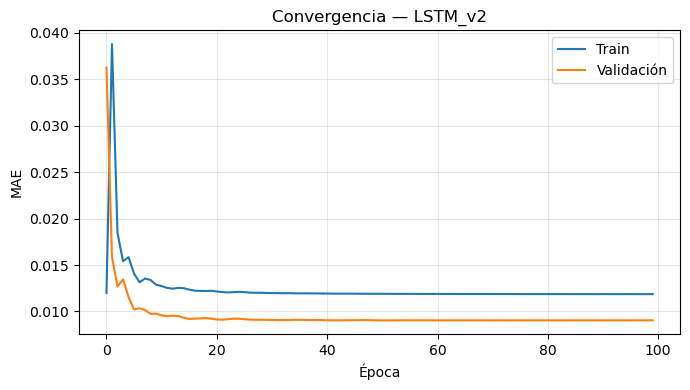

In [96]:
graficar_convergencia(hist_lstm_v2, 'LSTM_v2')
resultado_lstm_v2 = evaluar_modelo(modelo_lstm_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v2')
print(resultado_lstm_v2)

### Recurrente v3 -- GRU bidireccional

In [97]:
modelo_bigru = construir_recurrente_v3(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_bigru, lr=1e-2, l2=1e-100)
modelo_bigru.summary()
hist_bigru = modelo_bigru.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiGRU_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        10,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,439 (48.59 KB)

 Trainable params: 12,439 (48.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0136 - val_loss: 0.0298
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step - loss: 0.0319 - val_loss: 0.0172
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step - loss: 0.0201 - val_loss: 0.0149
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step - loss: 0.0180 - val_loss: 0.0169
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 890ms/step - loss: 0.0195 - val_loss: 0.0146
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step - loss: 0.0175 - val_loss: 0.0123
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step - loss: 0.0157 - val_loss: 0.0117
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step - loss: 0.0153 - val_loss: 0.0110
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step - loss: 0.0148 - val_loss: 0.0112
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step - loss: 0.0147 - val_loss: 0.0109
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step - loss: 0.0143 - val_loss: 0.0107
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step - loss: 0.0140

{'modelo': 'BiGRU_v3', 'mae_train': 0.011826461480244726, 'mae_val': 0.009060405552309095, 'mae_test': 0.012306969513446247, 'n_params': 12439}


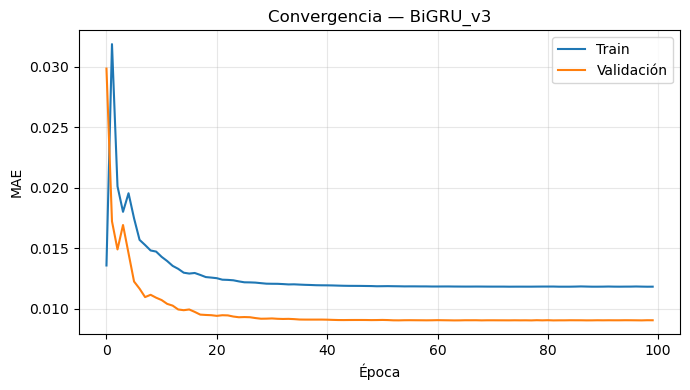

In [98]:
graficar_convergencia(hist_bigru, 'BiGRU_v3')
resultado_bigru = evaluar_modelo(modelo_bigru, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='BiGRU_v3')
print(resultado_bigru)

### Recurrente v4 -- LSTM + Dense intermedia (64 LSTM -> 32 Dense -> salida)

In [99]:
modelo_lstm_v4 = construir_recurrente_v4(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_lstm_v4, lr=1e-1, l2=1e-10)
modelo_lstm_v4.summary()
hist_lstm_v4 = modelo_lstm_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "LSTM_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,367 (99.09 KB)

 Trainable params: 25,367 (99.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0121 - val_loss: 0.1453
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1459 - val_loss: 0.2983
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.3070 - val_loss: 0.1144
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1341 - val_loss: 0.2399
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.2735 - val_loss: 1.3046
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1.3140 - val_loss: 0.4108
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.4798 - val_loss: 1.0912
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1.1076 - val_loss: 0.8252
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.8565 - val_loss: 0.3883
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.4470 - val_loss: 0.4273
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.4850 - val_loss: 0.4090
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.4698 - val_loss: 0.1228
Epoch 13/100


{'modelo': 'LSTM_v4', 'mae_train': 0.01197215951057873, 'mae_val': 0.009113699061266557, 'mae_test': 0.012330008237002178, 'n_params': 25367}


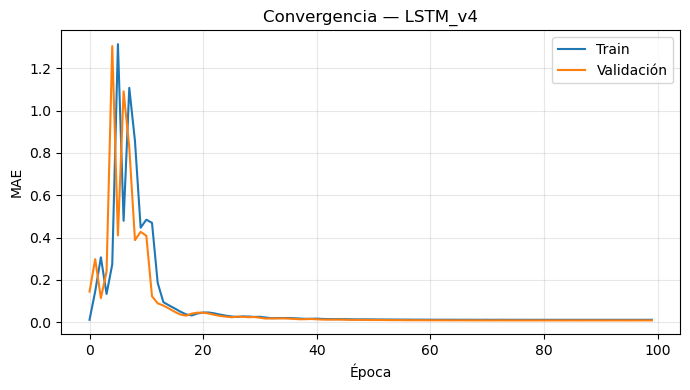

In [100]:
graficar_convergencia(hist_lstm_v4, 'LSTM_v4')

resultado_lstm_v4 = evaluar_modelo(modelo_lstm_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v4')
print(resultado_lstm_v4)

### Recurrente v5 -- LSTM 128 unidades con recurrent_dropout, LR=1e-4

In [101]:
modelo_lstm_v5 = construir_recurrente_v5(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_lstm_v5, lr=1e-2, l2=1e-10)
modelo_lstm_v5.summary()
hist_lstm_v5 = modelo_lstm_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "LSTM_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 128)            │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,791 (315.59 KB)

 Trainable params: 80,791 (315.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0122 - val_loss: 0.0327
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0338 - val_loss: 0.0206
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0221 - val_loss: 0.0128
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0153 - val_loss: 0.0126
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0149 - val_loss: 0.0108
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0134 - val_loss: 0.0101
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0128 - val_loss: 0.0107
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0132 - val_loss: 0.0098
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0126 - val_loss: 0.0098
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0125 - val_loss: 0.0099
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0126 - val_loss: 0.0097
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0124 - val_loss: 0.0096
Epoch 13/100


{'modelo': 'LSTM_v5', 'mae_train': 0.01181712744390567, 'mae_val': 0.009066227779693506, 'mae_test': 0.012303720903375748, 'n_params': 80791}


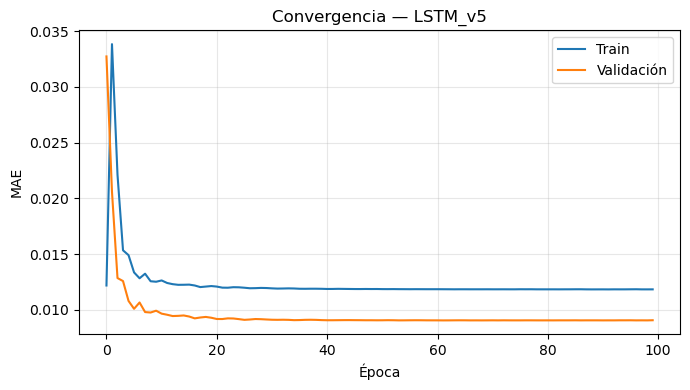

In [102]:
graficar_convergencia(hist_lstm_v5, 'LSTM_v5')
resultado_lstm_v5 = evaluar_modelo(modelo_lstm_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v5')
print(resultado_lstm_v5)

### Recurrente v6 -- 2 capas GRU apiladas (64->32)

In [103]:
modelo_gru_v6 = construir_recurrente_v6(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_gru_v6, lr=1e-2, l2=1e-10)
modelo_gru_v6.summary()
hist_gru_v6 = modelo_gru_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "GRU_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_10 (GRU)                    │ (None, 90, 64)         │        17,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,255 (106.46 KB)

 Trainable params: 27,255 (106.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.0123 - val_loss: 0.0417
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0451 - val_loss: 0.0241
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0275 - val_loss: 0.0187
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0216 - val_loss: 0.0184
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0215 - val_loss: 0.0160
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0194 - val_loss: 0.0128
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0164 - val_loss: 0.0118
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0152 - val_loss: 0.0115
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0150 - val_loss: 0.0115
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0151 - val_loss: 0.0110
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0147 - val_loss: 0.0104
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0140 - val_loss: 0.0102
Epoch 13/100


{'modelo': 'GRU_v6', 'mae_train': 0.011838762443781724, 'mae_val': 0.009047040669247148, 'mae_test': 0.012281593099484817, 'n_params': 27255}


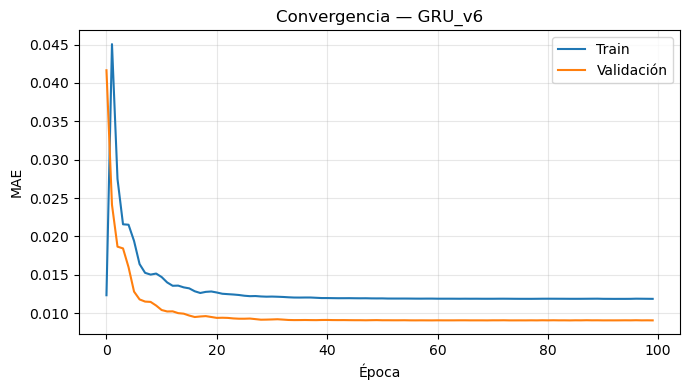

In [104]:
graficar_convergencia(hist_gru_v6, 'GRU_v6')
resultado_gru_v6 = evaluar_modelo(modelo_gru_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='GRU_v6')
print(resultado_gru_v6)

## 1.5 Modelos Conv1D

In [105]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_conv, lr=1e-1, l2=1e-10)

modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 88, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 88, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,415 (44.59 KB)

 Trainable params: 11,415 (44.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step - loss: 0.0131 - val_loss: 0.5287
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 0.5381 - val_loss: 0.0657
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - loss: 0.0668 - val_loss: 0.0325
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 0.0334 - val_loss: 0.0535
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 0.0538 - val_loss: 0.0459
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 0.0463 - val_loss: 0.0256
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - loss: 0.0269 - val_loss: 0.0283
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.0293 - val_loss: 0.0381
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - loss: 0.0388 - val_loss: 0.0363
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - loss: 0.0371 - val_loss: 0.0243
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 0.0258 - val_loss: 0.0217
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - loss: 0.0

{'modelo': 'Conv1D', 'mae_train': 0.011962220488238385, 'mae_val': 0.009112960546799855, 'mae_test': 0.014143072663641707, 'n_params': 11415}


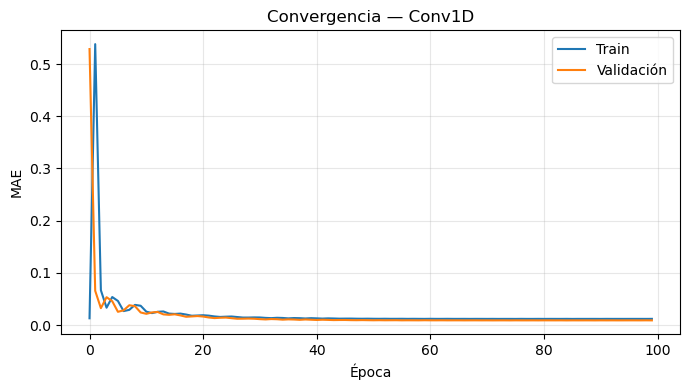

In [106]:
graficar_convergencia(hist_conv, 'Conv1D')

resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)

### Conv1D v2 -- 1 capa Conv1D + Flatten (modelo mas simple)

In [107]:
modelo_conv_v2 = construir_conv1d_v2(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_conv_v2, lr=1e-3, l2=1e-10)

modelo_conv_v2.summary()
hist_conv_v2 = modelo_conv_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_19 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2880)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 2880)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 23)             │        66,263 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,503 (267.59 KB)

 Trainable params: 68,503 (267.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step - loss: 0.0183 - val_loss: 0.0132
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.0181 - val_loss: 0.0121
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.0168 - val_loss: 0.0117
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0163 - val_loss: 0.0115
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0160 - val_loss: 0.0112
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - loss: 0.0155 - val_loss: 0.0108
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0150 - val_loss: 0.0105
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 0.0145 - val_loss: 0.0103
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 0.0142 - val_loss: 0.0101
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 0.0140 - val_loss: 0.0100
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.0138 - val_loss: 0.0099
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.0

{'modelo': 'Conv1D_v2', 'mae_train': 0.011806077996997111, 'mae_val': 0.009044708380395781, 'mae_test': 0.012365147908522035, 'n_params': 68503}


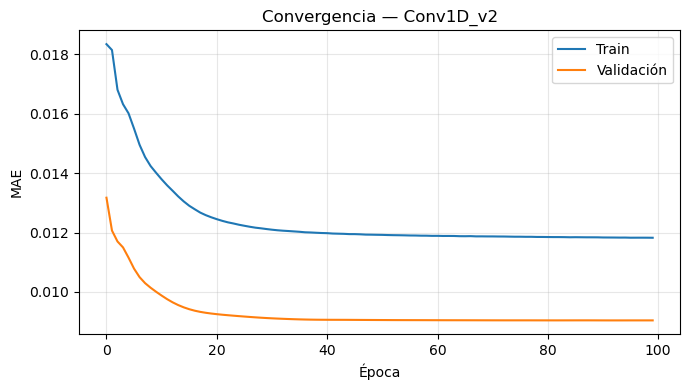

In [108]:
graficar_convergencia(hist_conv_v2, 'Conv1D_v2')
resultado_conv_v2 = evaluar_modelo(modelo_conv_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v2')
print(resultado_conv_v2)

### Conv1D v3 -- 3 capas Conv1D (64->32->16) + GlobalAveragePooling

In [109]:
modelo_conv_v3 = construir_conv1d_v3(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_conv_v3, lr=1e-1, l2=1e-10)

modelo_conv_v3.summary()
hist_conv_v3 = modelo_conv_v3.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 90, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 90, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 90, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 23)             │           391 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,599 (49.21 KB)

 Trainable params: 12,599 (49.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0133 - val_loss: 0.1801
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 0.1894 - val_loss: 0.0879
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - loss: 0.0881 - val_loss: 0.0651
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.0661 - val_loss: 0.0688
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - loss: 0.0691 - val_loss: 0.0479
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - loss: 0.0485 - val_loss: 0.0251
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 0.0266 - val_loss: 0.0381
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - loss: 0.0388 - val_loss: 0.0470
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - loss: 0.0474 - val_loss: 0.0444
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - loss: 0.0449 - val_loss: 0.0352
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - loss: 0.0364 - val_loss: 0.0268
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 0.0282

{'modelo': 'Conv1D_v3', 'mae_train': 0.012002602258887702, 'mae_val': 0.009143498166077355, 'mae_test': 0.012366785935040167, 'n_params': 12599}


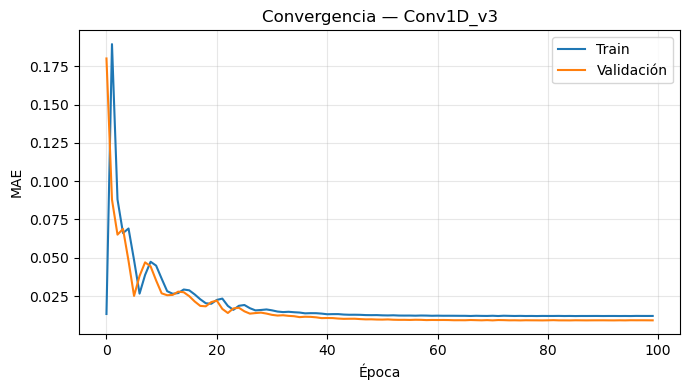

In [110]:
graficar_convergencia(hist_conv_v3, 'Conv1D_v3')
resultado_conv_v3 = evaluar_modelo(modelo_conv_v3, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v3')
print(resultado_conv_v3)

### Conv1D v4 -- Conv1D dilatada (dilation_rate=2), campo receptivo ampliado

In [111]:
modelo_conv_v4 = construir_conv1d_v4(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_conv_v4, lr=1e-2, l2=1e-10)

modelo_conv_v4.summary()
hist_conv_v4 = modelo_conv_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_23 (Conv1D)              │ (None, 90, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 90, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,415 (44.59 KB)

 Trainable params: 11,415 (44.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step - loss: 0.0127 - val_loss: 0.0163
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - loss: 0.0184 - val_loss: 0.0111
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - loss: 0.0136 - val_loss: 0.0098
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 0.0125 - val_loss: 0.0104
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - loss: 0.0130 - val_loss: 0.0108
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - loss: 0.0133 - val_loss: 0.0105
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - loss: 0.0130 - val_loss: 0.0099
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - loss: 0.0126 - val_loss: 0.0096
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - loss: 0.0123 - val_loss: 0.0097
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - loss: 0.0124 - val_loss: 0.0098
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - loss: 0.0125 - val_loss: 0.0098
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - loss: 0.0

{'modelo': 'Conv1D_v4', 'mae_train': 0.011899816267142944, 'mae_val': 0.009048182734459185, 'mae_test': 0.012286609553775472, 'n_params': 11415}


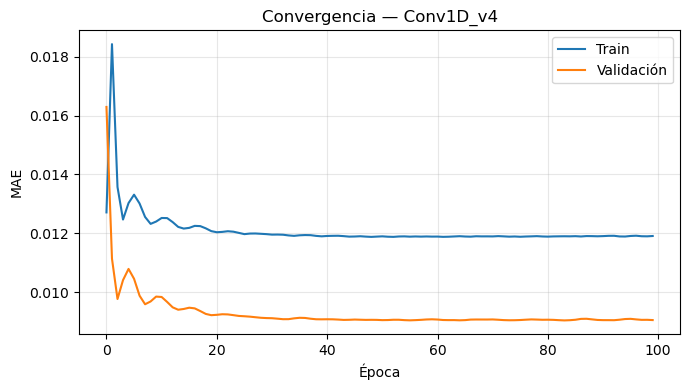

In [112]:
graficar_convergencia(hist_conv_v4, 'Conv1D_v4')
resultado_conv_v4 = evaluar_modelo(modelo_conv_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v4')
print(resultado_conv_v4)

### Conv1D v5 -- SeparableConv1D (menos parametros, mismo campo receptivo)

In [113]:
modelo_conv_v5 = construir_conv1d_v5(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_conv_v5, lr=1e-2, l2=1e-10)
modelo_conv_v5.summary()
hist_conv_v5 = modelo_conv_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "Conv1D_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d_6              │ (None, 90, 64)         │         1,605 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_7              │ (None, 90, 32)         │         2,272 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_11     │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,636 (18.11 KB)

 Trainable params: 4,636 (18.11 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step - loss: 0.0119 - val_loss: 0.0153
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 0.0173 - val_loss: 0.0099
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.0126 - val_loss: 0.0098
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.0125 - val_loss: 0.0110
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - loss: 0.0135 - val_loss: 0.0108
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 0.0133 - val_loss: 0.0099
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.0126 - val_loss: 0.0094
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.0122 - val_loss: 0.0096
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.0123 - val_loss: 0.0099
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.0125 - val_loss: 0.0100
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 0.0126 - val_loss: 0.0097
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.0

{'modelo': 'Conv1D_v5', 'mae_train': 0.011876321968575276, 'mae_val': 0.009049889569981828, 'mae_test': 0.012276342807220161, 'n_params': 4636}


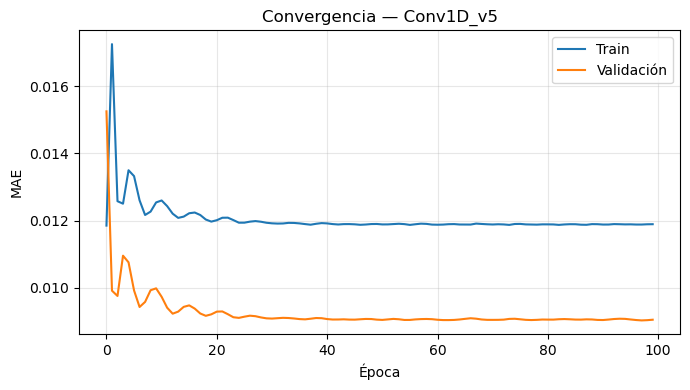

In [114]:
graficar_convergencia(hist_conv_v5, 'Conv1D_v5')
resultado_conv_v5 = evaluar_modelo(modelo_conv_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v5')
print(resultado_conv_v5)

### Conv1D v6 -- Conv1D + MaxPooling1D + Flatten

In [115]:
modelo_conv_v6 = construir_conv1d_v6(X_train.shape[1:], y_train.shape[1])
modelo_conv_v6.summary()
hist_conv_v6 = modelo_conv_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Conv1D_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 90, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 45, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 23)             │        33,143 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,799 (171.09 KB)

 Trainable params: 43,799 (171.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step - loss: 0.0207 - val_loss: 0.0111
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - loss: 0.0156 - val_loss: 0.0107
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 0.0146 - val_loss: 0.0104
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.0141 - val_loss: 0.0100
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.0135 - val_loss: 0.0097
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.0130 - val_loss: 0.0094
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.0126 - val_loss: 0.0093
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.0123 - val_loss: 0.0092
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - loss: 0.0122 - val_loss: 0.0091
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.0121 - val_loss: 0.0091
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 0.0120 - val_loss: 0.0091
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - loss: 0.0

{'modelo': 'Conv1D_v6', 'mae_train': 0.011839687815727175, 'mae_val': 0.009038602381488205, 'mae_test': 0.012282839384171957, 'n_params': 43799}


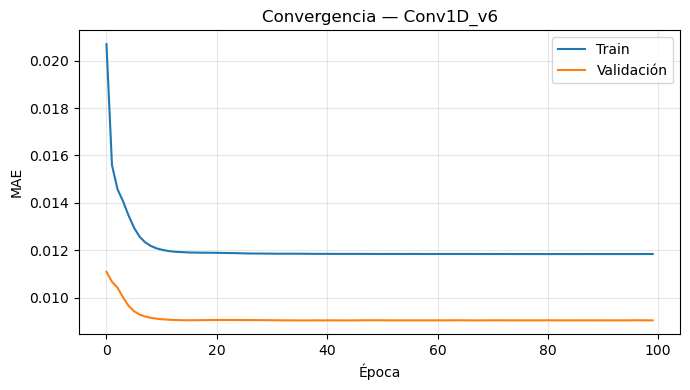

In [116]:
graficar_convergencia(hist_conv_v6, 'Conv1D_v6')
resultado_conv_v6 = evaluar_modelo(modelo_conv_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v6')
print(resultado_conv_v6)

## 1.6 Modelo Mixto (Conv1D + LSTM)

In [117]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
aplicar_hp(modelo_mixto, lr=1e-3, l2=1e-10)
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=30000,   verbose=1)

Model: "Mixto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_58 (InputLayer)     │ (None, 90, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 90, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,999 (152.34 KB)

 Trainable params: 38,999 (152.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0123 - val_loss: 0.0095
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0123 - val_loss: 0.0093
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0122 - val_loss: 0.0093
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0121 - val_loss: 0.0093
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0121 - val_loss: 0.0092
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0121 - val_loss: 0.0091
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0120 - val_loss: 0.0091
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0120 - val_loss: 0.0091
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0120 - val_loss: 0.0091
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0120 - val_loss: 0.0091
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0120 - val_loss: 0.0091
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0120 - val_loss: 0.0091
Epoch 13/100


{'modelo': 'Mixto', 'mae_train': 0.011815293194015055, 'mae_val': 0.009048258420132484, 'mae_test': 0.012298288923776985, 'n_params': 38999}


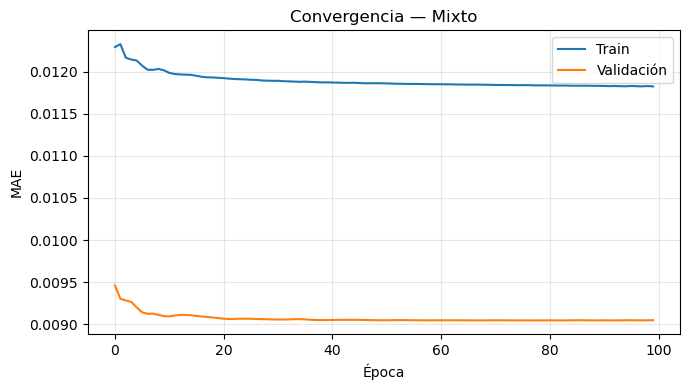

In [118]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

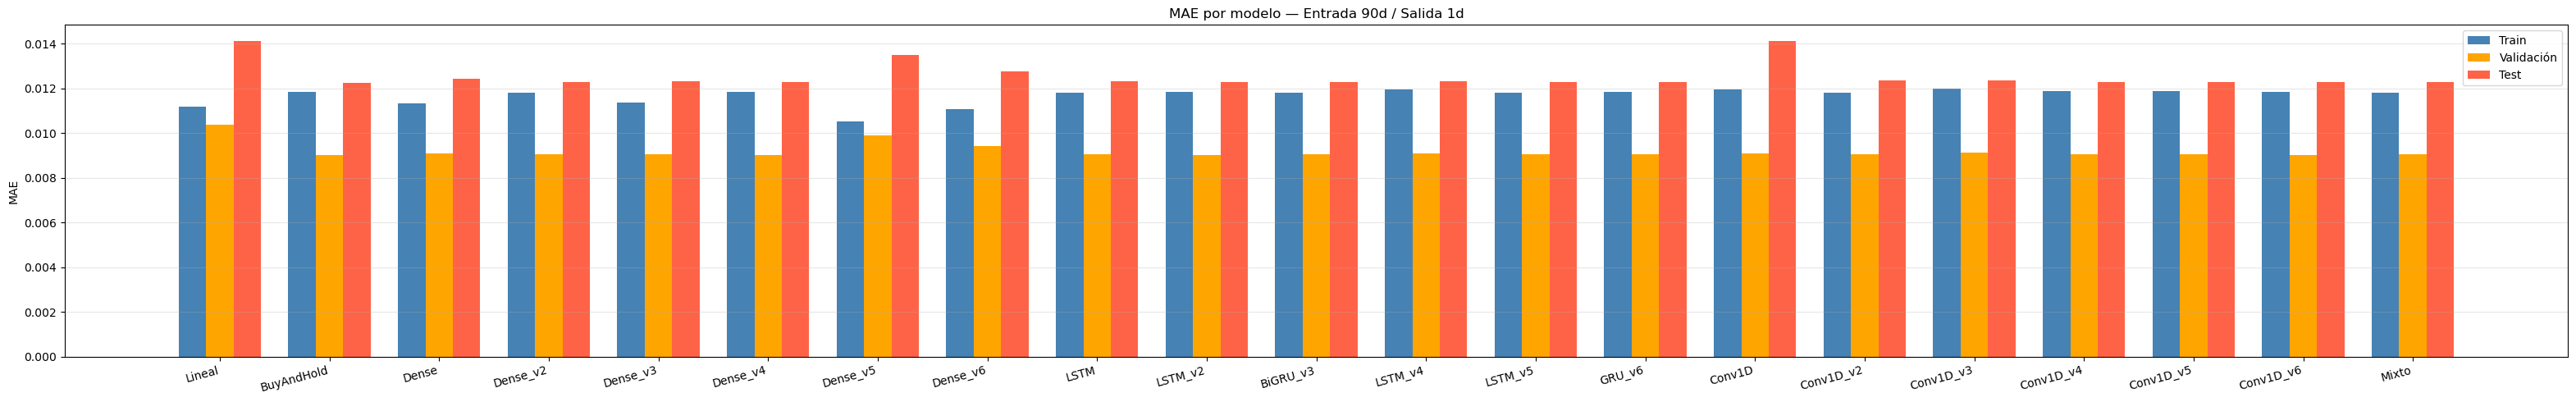

Resultados [competicion] guardados en: ../resultados/metricas/ent90_sal01.json


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.011190,0.010370,0.014121,0
BuyAndHold,0.011859,0.009026,0.012271,0
Dense,0.011318,0.009101,0.012443,566039
Dense_v2,0.011799,0.009041,0.012287,276183
Dense_v3,0.011356,0.009077,0.012341,1234327
Dense_v4,0.011843,0.009040,0.012282,274839
Dense_v5,0.010535,0.009905,0.013493,536087
Dense_v6,0.011063,0.009411,0.012783,79671
LSTM,0.011813,0.009070,0.012312,24023


In [119]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    # Dense
    resultado_dense, resultado_dense_v2, resultado_dense_v3,
    resultado_dense_v4, resultado_dense_v5, resultado_dense_v6,
    # Recurrente
    resultado_lstm, resultado_lstm_v2, resultado_bigru,
    resultado_lstm_v4, resultado_lstm_v5, resultado_gru_v6,
    # Conv1D
    resultado_conv, resultado_conv_v2, resultado_conv_v3,
    resultado_conv_v4, resultado_conv_v5, resultado_conv_v6,
    # Mixto
    resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))

---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [120]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


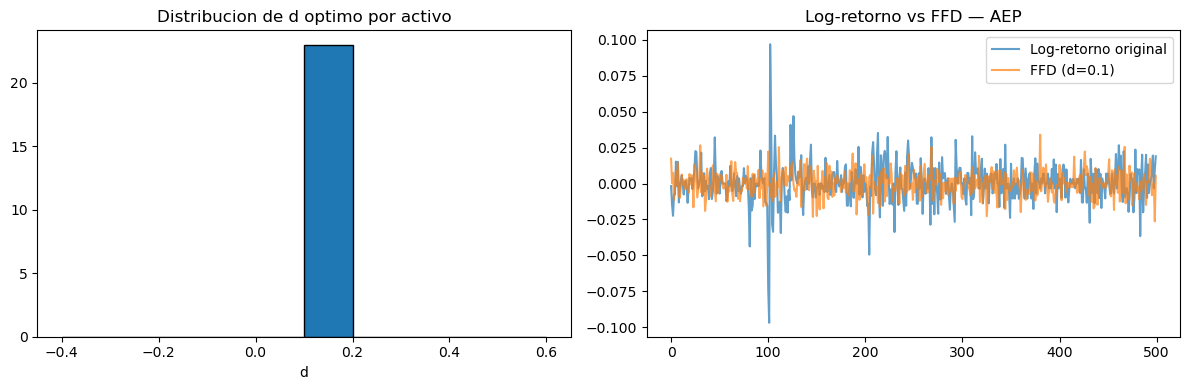

In [121]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [122]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de senyal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


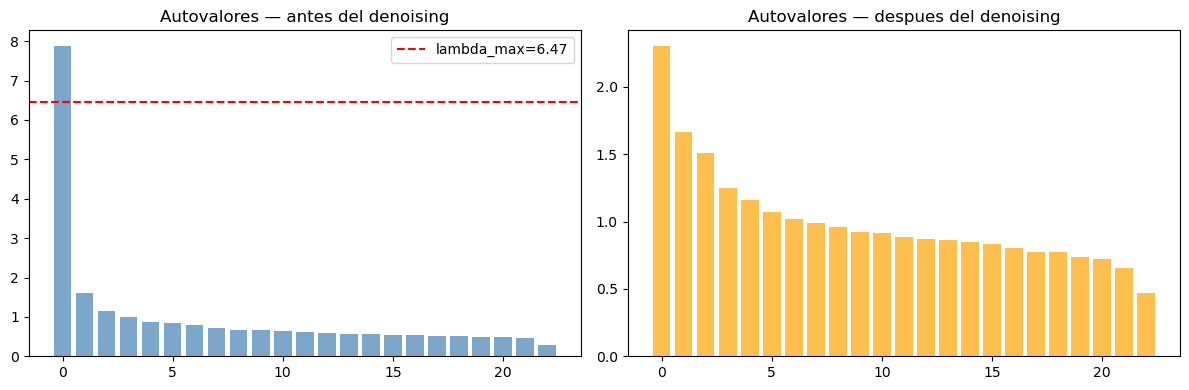

In [123]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [124]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)
Train: (12636, 90, 23)  Val: (1404, 90, 23)  Test: (1561, 90, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

Mejor modelo Parte 1 (redes neuronales): Mixto
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.7217 - val_loss: 0.5415
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7149 - val_loss: 0.5405
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7126 - val_loss: 0.5409
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7119 - val_loss: 0.5412
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7112 - val_loss: 0.5409
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7106 - val_loss: 0.5404
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7098 - val_loss: 0.5398
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7089 - val_loss: 0.5392
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7082 - val_loss: 0.5388
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7074 - val_loss: 0.5385
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.7072 - val_loss: 0.5382
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step 

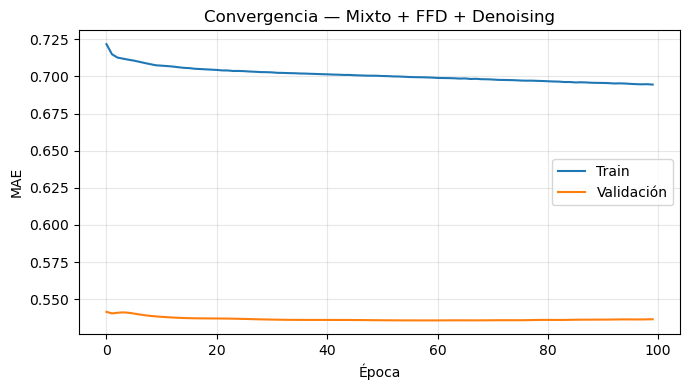

In [125]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=30000,   verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Mixto,0.011815,0.009048,0.012298,38999
Mixto_prep,0.692834,0.536549,0.715383,38999


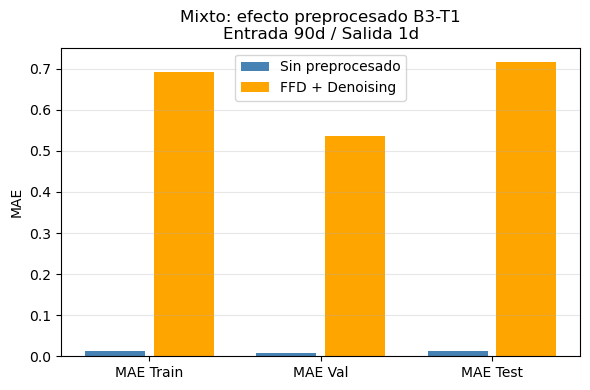

Variacion MAE test con preprocesado: -5716.9%
Resultados [investigacion] guardados en: ../resultados/metricas/ent90_sal01.json


In [126]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
